In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Einführung in Seaborn

Seaborn ist eine Pythonbibliothek zur statistischen Datenvisualisierung, die auf Matplotlib aufbaut und besonders gut mit pandas DataFrames zusammenarbeitet. Sie bietet eine hohe Abstraktionsebene und integriert statistische Elemente direkt in die Plots. Ich lasse einen Datenframe erstellen, um damit zu arbeiten:

In [21]:
data = {
    'Alter': np.random.normal(35, 8, 80).astype(int),
    'Gehalt': np.random.normal(55000, 12000, 80).astype(int),
    'Abteilung': np.random.choice(['IT', 'Marketing', 'Finanz', 'HR'], 80),
    'Erfahrung': np.random.randint(1, 20, 80),
    'Geschlecht': np.random.choice(['m', 'w'], 80)
}

df = pd.DataFrame(data)
print(df)

    Alter  Gehalt  Abteilung  Erfahrung Geschlecht
0      42   59296     Finanz          1          m
1      50   40589     Finanz          9          m
2      37   78809     Finanz         15          m
3      56   58740  Marketing         19          m
4      46   46977     Finanz          9          w
..    ...     ...        ...        ...        ...
75     42   45399         IT         13          m
76     42   78495         IT          5          w
77     35   55997  Marketing         17          m
78     32   51491  Marketing          8          w
79     26   40639     Finanz         14          m

[80 rows x 5 columns]


Um ein einfaches Streudiagramm in Abhängigkeit von ALter und Gehalt zu erstellen, genügt der Code:

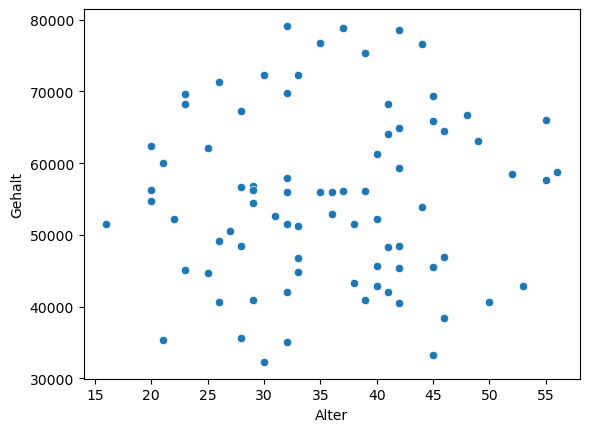

In [22]:
sns.scatterplot(data=df, x="Alter", y="Gehalt")
plt.show()

Um ein Balkendiagramm der Häufigkeiten des Geschlechts zu erstellen, genügt:

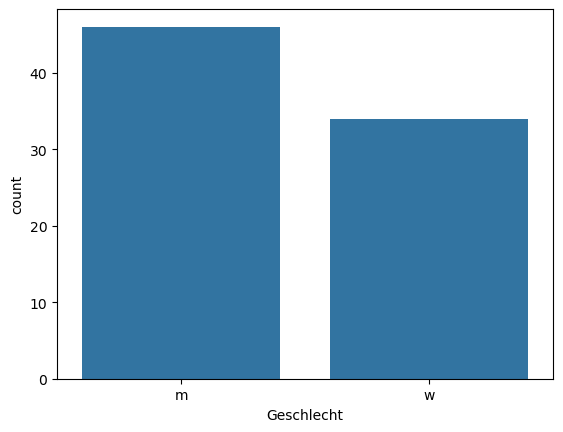

In [23]:
sns.countplot(data=df, x="Geschlecht")
plt.show()

## Tidy vs Untidy Datensätze

Tidy Daten liegen vor, wenn jede Variable eine eigene Spalte bildet, jede Beobachtung (jeder Fall) eine eigene Zeile darstellt und jede Zelle genau einen Wert enthält. In diesem Format ist jede Information klar getrennt und strukturiert. Seaborn, pandas und die meisten modernen Visualisierungs- und Analysebibliotheken arbeiten am besten und einfachsten mit tidy Daten. Funktionen wie `hue=`, `style=` oder `col=` können direkt auf Spalten zugreifen, ohne dass vorher umgeformt werden muss.

Untidy Daten liegen hingegen vor, wenn Werte einer Variablen über mehrere Spalten verteilt sind. Häufig stehen Kategorien als Spaltenüberschriften (z. B. `Gehalt_IT`, `Gehalt_Marketing`, `Gehalt_Finanz`) oder Messwerte zu verschiedenen Zeitpunkten sind in separaten Spalten abgelegt. Solche Daten sind für Menschen manchmal übersichtlicher, aber für Seaborn und statistische Auswertungen unpraktisch, da viele Funktionen nicht direkt damit arbeiten können.

In [24]:
# Tidy Datensatz
tidy_data = pd.DataFrame({
    'Mitarbeiter': [1, 2, 3, 4, 5, 6],
    'Abteilung': ['IT', 'IT', 'Marketing', 'Marketing', 'Finanz', 'Finanz'],
    'Geschlecht': ['m', 'w', 'm', 'w', 'm', 'w'],
    'Gehalt': [62000, 58000, 51000, 49000, 67000, 64000],
    'Alter': [34, 29, 41, 38, 45, 36]
})

print(tidy_data)

   Mitarbeiter  Abteilung Geschlecht  Gehalt  Alter
0            1         IT          m   62000     34
1            2         IT          w   58000     29
2            3  Marketing          m   51000     41
3            4  Marketing          w   49000     38
4            5     Finanz          m   67000     45
5            6     Finanz          w   64000     36


In [25]:
# Untidy Datensatz
untidy_data = pd.DataFrame({
    'Mitarbeiter': [1, 2, 3, 4, 5, 6],
    'Gehalt_IT': [62000, 58000, None, None, None, None],
    'Gehalt_Marketing': [None, None, 51000, 49000, None, None],
    'Gehalt_Finanz': [None, None, None, None, 67000, 64000],
    'Alter': [34, 29, 41, 38, 45, 36]
})

print(untidy_data)

   Mitarbeiter  Gehalt_IT  Gehalt_Marketing  Gehalt_Finanz  Alter
0            1    62000.0               NaN            NaN     34
1            2    58000.0               NaN            NaN     29
2            3        NaN           51000.0            NaN     41
3            4        NaN           49000.0            NaN     38
4            5        NaN               NaN        67000.0     45
5            6        NaN               NaN        64000.0     36


## Die `hue=` Funktion

Die `hue` Funktion erlaubt es, eine zusätzliche kategoriale Variable farblich in den Plot einzubringen. Dadurch werden Gruppen innerhalb der Daten automatisch farblich unterschieden. Im folgenden Beispiel kann man durch `hue="Abteilung"` das Streudiagramm in Abhängigkeit von ALter und Gehalt nach Abteilungen (jeweils eigene Farben) aufspalten bzw. kategorisch sichtbar machen. 

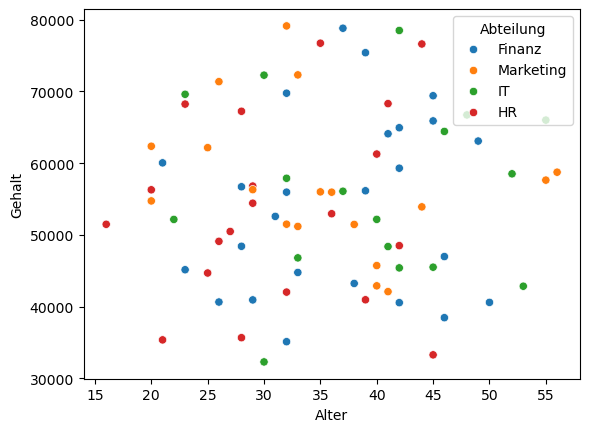

In [26]:
sns.scatterplot(
    data=df,
    x='Alter',
    y='Gehalt',
    hue='Abteilung'         
)
plt.show()

Mit den Funktionen `palette` und `hue_order`lassen sich zum einen die dargestellten Farben, als auch die Reihenfolge der Farben steuern. Dies geschieht in der Form von Listen oder pandas Daten. Es gibt auch vorprogrammierte Sets für die Ordnung der Farben (z.B. `palette` = 'Set1')

<Axes: xlabel='Alter', ylabel='Gehalt'>

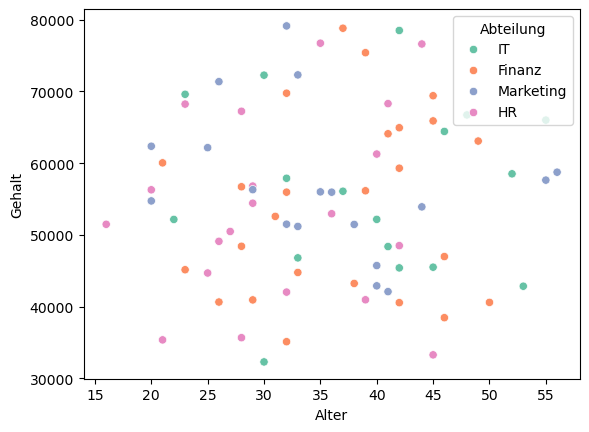

In [27]:
sns.scatterplot(
    data=df,
    x='Alter',
    y='Gehalt',
    hue='Abteilung',
    hue_order=['IT', 'Finanz', 'Marketing', 'HR'],   # gewünschte Reihenfolge
    palette='Set2'
)

# Visualisierungen von 2 quantitativen Variablen

Relational Plots zeigen Beziehungen zwischen zwei numerischen Variablen, wie im vorherigen Kapitel die Beziehung zwischen Gehalt und Alter oder auch die Beziehung zwischen Größe und Gewicht. Durch die Funktion `hue=` kann man diese Beziehungen in eine weitere Variable fablich unterscheiden. Nun soll es darum gehen, dass man die Kategorisierung wie durch die `hue=` Funktion zuvor innerhalb eines Diagrammes in 2 Plots darstellt. Solche Diagramme sind vor allem nützlich für Vergleiche.
Die wichtigste Funktion dafür ist `sns.relplot()`.

## Relational Plots und Subplots in Seaborn

### Streudiagramme
Mit dem Befehl `kind='scatter'` kann man die Art des Diagramms (Streudiagramm, Liniendiagramm) festsetzen und der Befehl `col='Abteilung'` gibt an, dass die Subplots in jeweils einer eigenen Spalte (Nach Abteilung) aufgelistet werden sollen. 

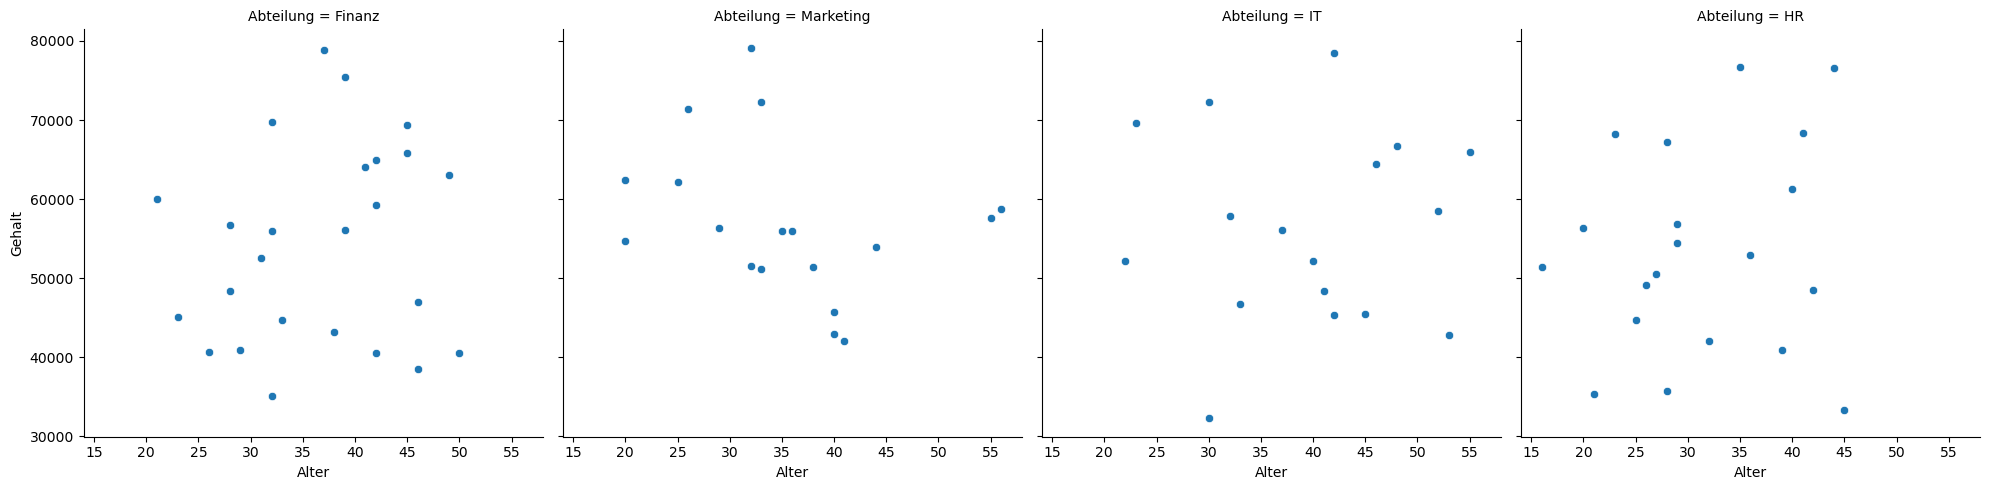

In [28]:
sns.relplot(
    data=df,
    x='Alter',
    y='Gehalt',
    kind='scatter',          
    col='Abteilung',        
)
plt.show()

Äquivalent dazu sorgt `col='Abteilung'` für eine Zeilenweise Auflistung der Subplots

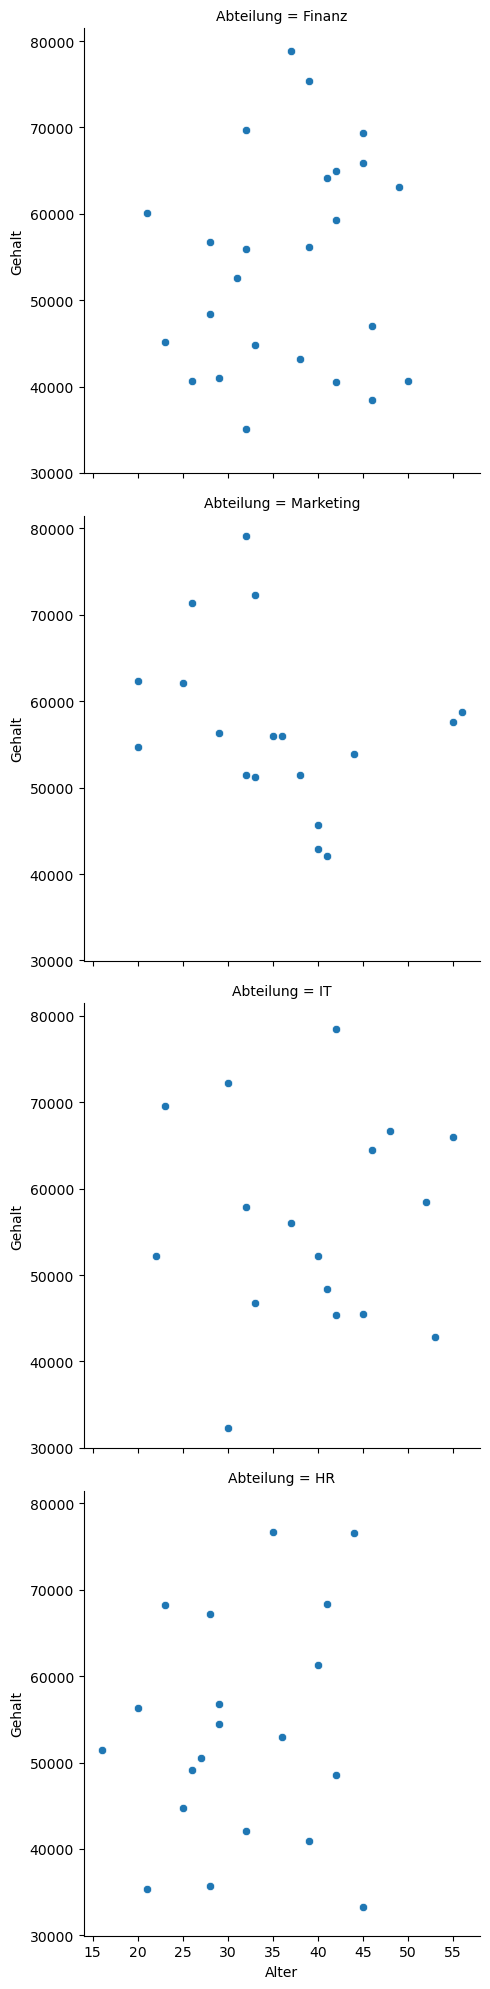

In [29]:
sns.relplot(
    data=df,
    x='Alter',
    y='Gehalt',
    kind='scatter',          
    row='Abteilung',        
)
plt.show()

Mit `col_order` und `row_order` sind wichtige Parameter bei `relplot()`, die es ermöglichen, die Reihenfolge der Subplots  vollständig selbst zu bestimmen. Standardmäßig sortiert Seaborn die Subplots alphabetisch nach den Kategorien. Mit `col_order` und `row_order` kann man eine  gewünschte Reihenfolge erzwingen. 

Besonders nützlich ist dies bei der Darstellung mehrerer Gruppen (z. B. Abteilungen, Regionen oder Altersgruppen), damit der Betrachter die Plots leichter vergleichen kann. Während `col=` die Subplots horizontal anordnet und `row=` vertikal, sorgen `col_order` und `row_order` dafür, dass die Reihenfolge der einzelnen Facetten nicht dem Zufall überlassen bleibt:

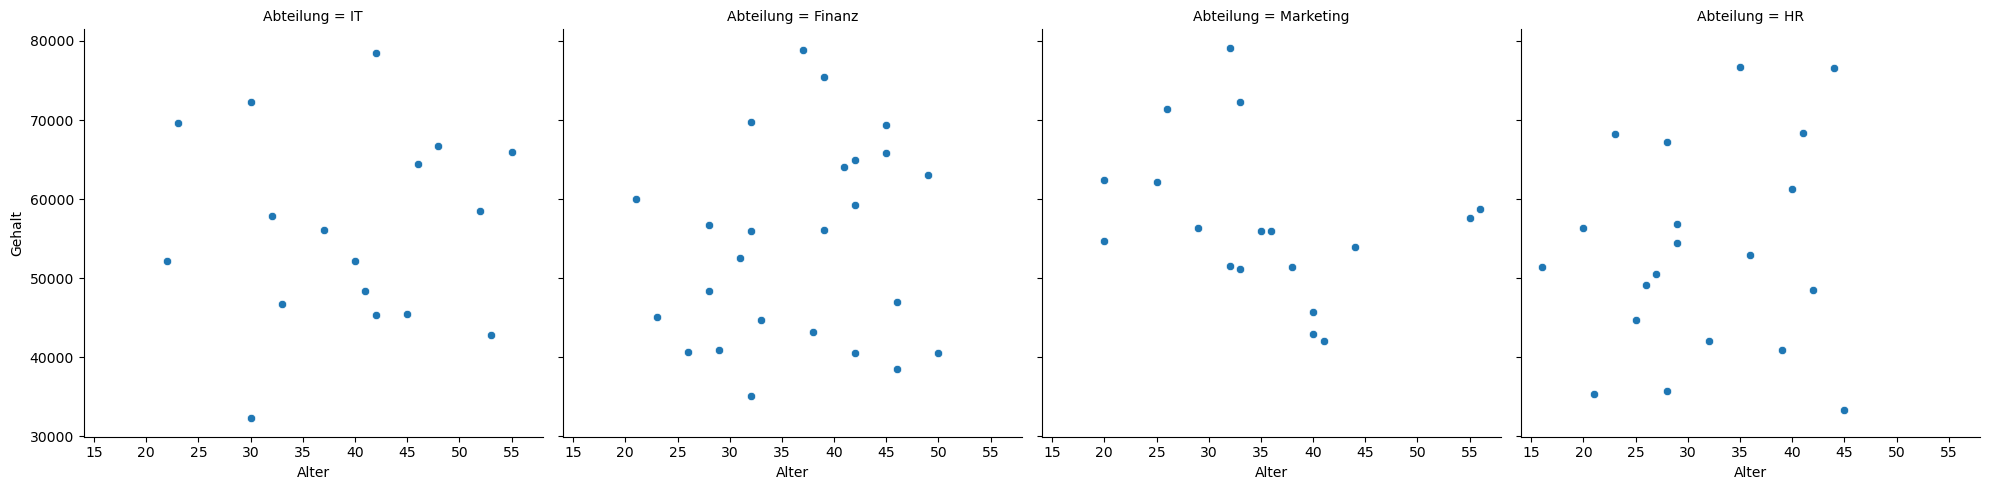

In [30]:
sns.relplot(data=df, x='Alter', y='Gehalt', col='Abteilung',
            col_order=['IT', 'Finanz', 'Marketing', 'HR'], 
            )

### Liniendiagramme

Der Parameter `kind='line'` wandelt den `relplot()` von einem Streudiagramm (Scatterplot) in ein Liniendiagramm um. 
Er wird vor allem verwendet, um Entwicklungen, Trends und Verläufe über eine kontinuierliche Variable (z. B. Zeit, Alter, Erfahrung) darzustellen.

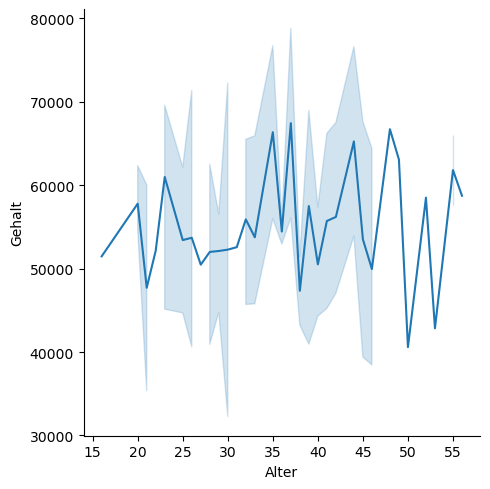

In [31]:
sns.relplot(
    data=df,
    x='Alter',
    y='Gehalt',
    kind='line',               
)

## Anpassen und Individualisieren von Plots

### Streudiagramm

Die Parameter `size` und `style` erlauben es, zwei zusätzliche Variablen in einem Scatterplot oder Lineplot visuell darzustellen, die die Größe und das Symbol verändern.

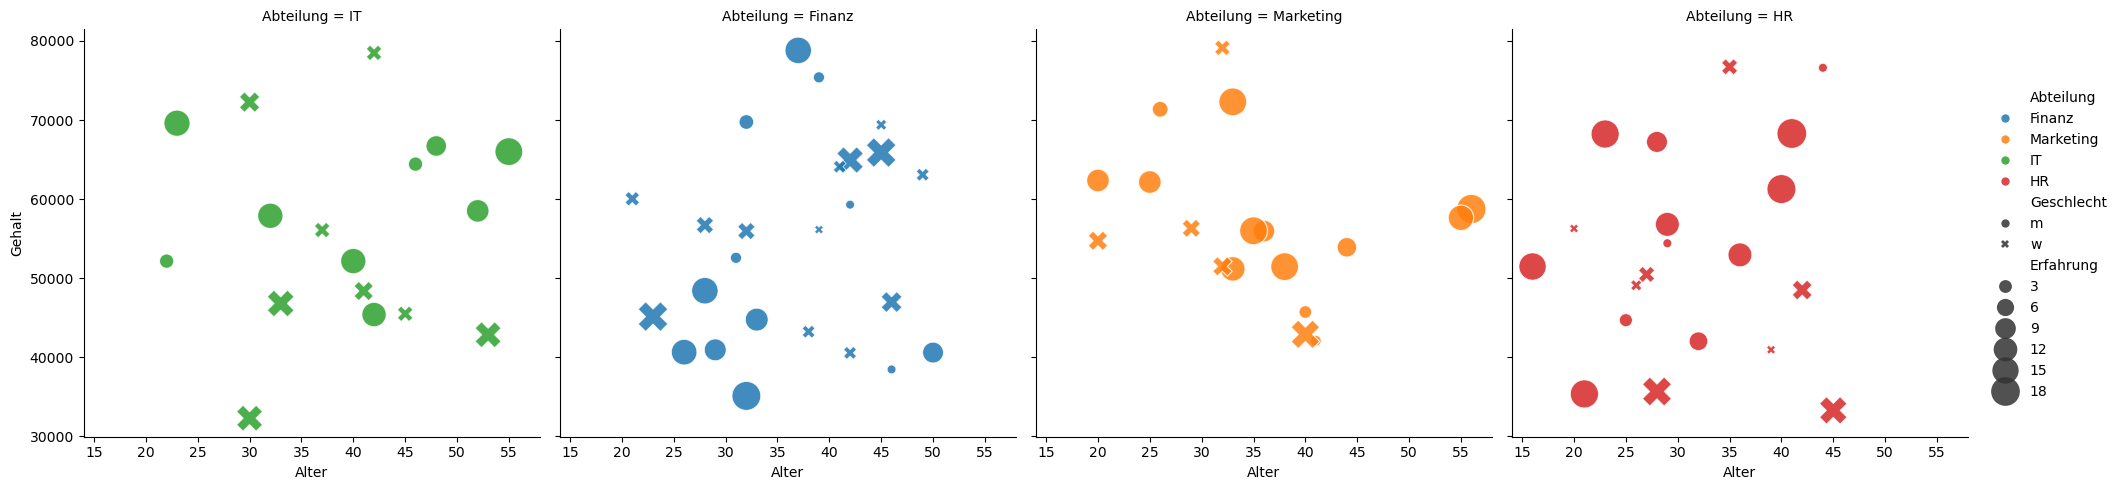

In [32]:
sns.relplot(
    data=df,
    x='Alter',
    y='Gehalt',
    hue='Abteilung',            
    style='Geschlecht',         
    size='Erfahrung',           
    col='Abteilung',
    col_order=['IT', 'Finanz', 'Marketing', 'HR'],
    sizes=(40, 450),
    alpha=0.85
)

### Liniendiagramm

Die 3 Parameter `errorbar`, `markers` und `dashes` werden besonders bei Liniendiagrammen (`kind='line'`) häufig verwendet und helfen, Plots klarer und informativer zu gestalten. Mit `errorbar` steuert man die Darstellung von Unsicherheit (z. B. Konfidenzintervalle oder Standardabweichung). Mit `errorbar=sd` ändert man den Durchschnitt auf Standardabweichung oder `errorbar=None` ohne Fehlerabweichungen.
Mit `markers=True` kann man die Datenpunkte auf den Linien aktivieren und `=False` deaktivieren. `dashes=True` aktiviert gestrichelte/gepunktete Linien. 

# Kategorielle Diagramme

## Säulen und Balkendiagramme 

Die zentrale Funktion dafür ist `sns.catplot()`, der  automatisch Subplots erzeugen kann.

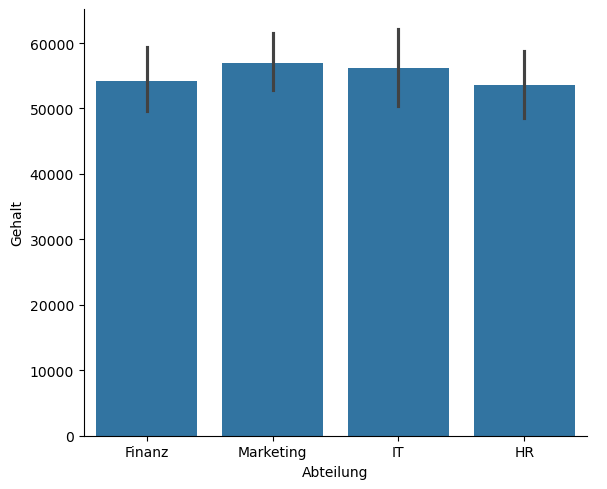

In [33]:
sns.catplot(
    data=df,
    x='Abteilung',           # kategoriale Variable auf x-Achse
    y='Gehalt',              # numerische Variable (meist Mittelwert)
    kind='bar',              # ← entscheidet den Diagrammtyp
    height=5,
    aspect=1.2
)

Im folgenden Beispiel teilt `hue='Geschlecht'` jede Säule farblich nach Geschlecht auf, sodass pro Abteilung zwei nebeneinanderstehende Balken (männlich und weiblich) entstehen. Mit `order=['IT', 'Finanz', 'Marketing', 'HR']` wird die Reihenfolge der Abteilungen auf der x-Achse explizit festgelegt, anstatt der automatischen alphabetischen Sortierung. Der Parameter `errorbar=('ci', 95)` fügt oben auf jeder Säule Fehlerbalken hinzu, die das 95%-Konfidenzintervall des Mittelwerts darstellen und somit die statistische Unsicherheit visualisieren. Zusammen ermöglichen diese Parameter einen übersichtlichen, logisch sortierten und statistisch aussagekräftigen Säulenplot.

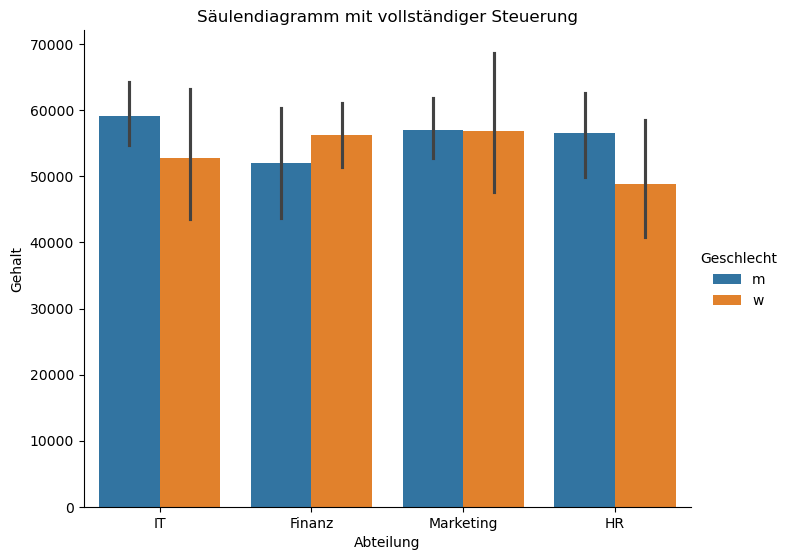

In [34]:
sns.catplot(
    data=df,
    x='Abteilung',
    y='Gehalt',
    kind='bar',
    hue='Geschlecht',
    order=['IT', 'Finanz', 'Marketing', 'HR'],   # gewünschte Reihenfolge
    errorbar=('ci', 95),
    palette='tab10',
    height=5.5,
    aspect=1.3
)
plt.title('Säulendiagramm mit vollständiger Steuerung')
plt.show()

## Boxplot

Ein Boxplot ist ein kategorisches Diagramm, das die Verteilung einer numerischen Variable über verschiedene Kategorien hinweg übersichtlich darstellt. Er zeigt Median, Quartile, Spannweite und mögliche Ausreißer auf einen Blick.

Mit Seaborn erstellt man Boxplots am besten mit `catplot()` und dem Parameter `kind='box'`:


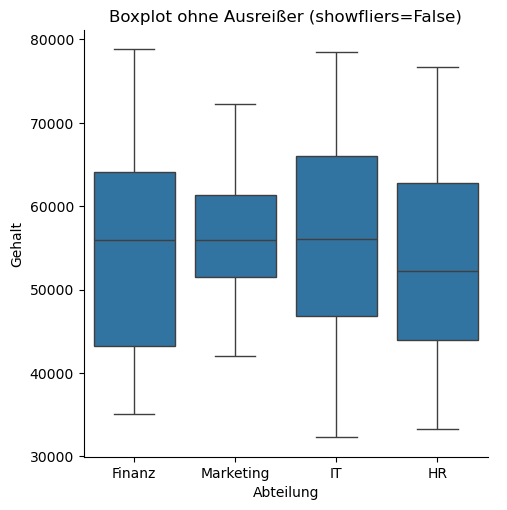

In [35]:
sns.catplot(
    data=df,
    x='Abteilung',
    y='Gehalt',
    kind='box',
    showfliers=False,          # Ausreißer ausblenden
)
plt.title('Boxplot ohne Ausreißer (showfliers=False)')
plt.show()

`showfliers` steuert die Darstellung von Ausreißern.
Standardmäßig werden Ausreißer als einzelne Punkte außerhalb der Whisker angezeigt. Setzt man showfliers=False, werden diese Punkte ausgeblendet.

## Punktediagramm

Ein Punktediagramm ist eine elegante Mischform aus Säulendiagramm und Liniendiagramm. Es zeigt den geschätzten Mittelwert (oder einen anderen Schätzer) einer numerischen Variable pro Kategorie als Punkt und visualisiert zusätzlich die Unsicherheit durch Fehlerbalken. Es wird mit `catplot()` und `kind='point'` erstellt und eignet sich besonders gut zum Vergleich von Mittelwerten über Kategorien. `estimator` legt fest, welcher Wert pro Kategorie dargestellt wird. `errorbar` steuert die Fehlerbalken. `capsize` bestimmt die Größe der horizontalen Querstriche an den Enden der Fehlerbalken. `linestyle` verändert den Stil der Verbindungslinien zwischen den Punkten.

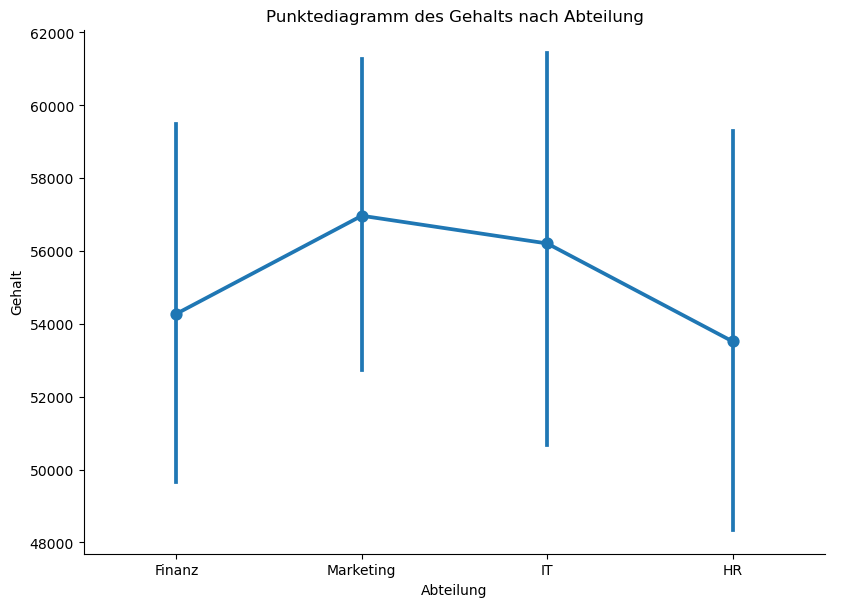

In [36]:
sns.catplot(
    data=df,
    x='Abteilung',
    y='Gehalt',
    kind='point',              # Punktediagramm
    height=6,
    aspect=1.4
)
plt.title('Punktediagramm des Gehalts nach Abteilung')
plt.show()

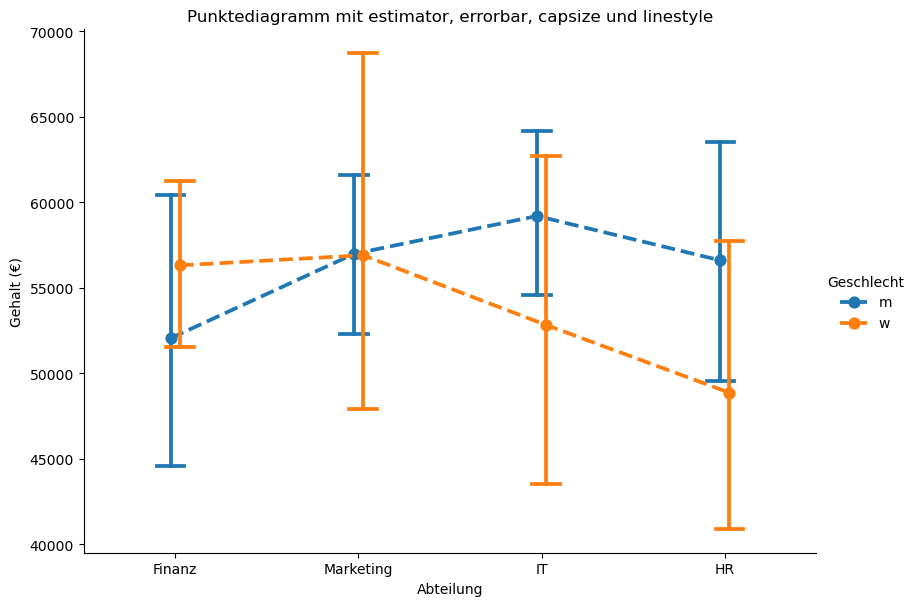

In [37]:
sns.catplot(
    data=df,
    x='Abteilung',
    y='Gehalt',
    kind='point',
    hue='Geschlecht',
    
    estimator='mean',              # Mittelwert
    errorbar=('ci', 95),           # 95% Konfidenzintervall
    capsize=0.15,                  # Länge der Fehlerbalken-Kappen
    linestyle='--',                # gestrichelte Verbindungslinien
    markers='o',                   # Punktform
    palette='tab10',
    height=6,
    aspect=1.4,
    dodge=True                     # Balken leicht versetzen bei hue
)

plt.title('Punktediagramm mit estimator, errorbar, capsize und linestyle')
plt.ylabel('Gehalt (€)')
plt.show()

# Style und Farben von Diagrammen verändern

## Style und Farben ändern
sns.set_style
sns.set_palette()
sns.set_context() "notebook", "paper", "talk", "poster", "darkgrid"

## Titel und Beschriftungen
FacetGrid 
g.figure.suptitle("", y = Größe)


AxesSubplot
g.set_title("")

g.set(xlabel= "", ylabel="")
plt.xticks(rotation=90)

 